In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/telco_customer_data_v2.csv')

In [5]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes


In [6]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
69995,CUST69996,Male,1,Yes,Yes,30.0,Yes,Yes,Fiber optic,Yes,...,No,Yes,No,No,Two year,No,Electronic check,74.85,2245.5,No
69996,CUST69997,Male,0,Yes,NaN,15.0,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),40.67,610.05,Yes
69997,CUST69998,Male,0,NaN,No,20.0,Yes,No,DSL,Yes,...,No,No,NaN,No,Month-to-month,Yes,Mailed check,29.44,588.8,No
69998,CUST69999,Male,0,No,No,21.0,Yes,No,Fiber optic,No,...,No,No,Yes,No internet service,Month-to-month,Yes,Electronic check,46.77,982.17,No
69999,CUST70000,Female,0,No,No,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,72.41,217.23,Yes


In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            69252 non-null  object 
 2   SeniorCitizen     69341 non-null  object 
 3   Partner           66470 non-null  object 
 4   Dependents        66435 non-null  object 
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     68132 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    67078 non-null  object 
 10  OnlineBackup      67253 non-null  object 
 11  DeviceProtection  67106 non-null  object 
 12  TechSupport       67267 non-null  object 
 13  StreamingTV       67173 non-null  object 
 14  StreamingMovies   67215 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

In [9]:
df.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


In [10]:
df.shape

(70000, 21)

In [11]:
df.isnull().sum()

,0
customerID,0
gender,748
SeniorCitizen,659
Partner,3530
Dependents,3565
tenure,567
PhoneService,0
MultipleLines,1868
InternetService,0
OnlineSecurity,2922


In [12]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [13]:
df['SeniorCitizen'] = df['SeniorCitizen'].fillna(df['SeniorCitizen'].mode()[0])

In [14]:
df['Partner'] = df['Partner'].fillna(df['Partner'].mode()[0])

In [15]:
for col in df:
  if df[col].dtype == 'object':
    df[col] = df[col].fillna(df[col].mode()[0])
  else:
    df[col] = df[col].fillna(df[col].mean())

In [16]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [17]:
print(df.duplicated().sum())

0


In [18]:
for col in df:
  if df[col].dtype == 'object':
    print(col,df[col].unique())

customerID ['CUST00001' 'CUST00002' 'CUST00003' ... 'CUST69998' 'CUST69999'
 'CUST70000']
gender ['Male' 'Female' 'f' 'Man' 'FEMALE' 'm' 'male']
SeniorCitizen ['0' '1' 'No' 'Yes' 'not senior']
Partner ['No' 'Yes']
Dependents ['Yes' 'No']
PhoneService ['Yes' 'No']
MultipleLines ['Yes' 'No' 'No phone service']
InternetService ['No' 'DSL' 'Fiber optic']
OnlineSecurity ['No internet service' 'No' 'Yes' 'Y' 'True']
OnlineBackup ['No internet service' 'No' 'Yes' 'Y' 'True']
DeviceProtection ['No internet service' 'No' 'Yes' 'Y' 'True']
TechSupport ['No internet service' 'Yes' 'No' 'Y' 'True']
StreamingTV ['No internet service' 'No' 'Yes' 'Y' 'True']
StreamingMovies ['No internet service' 'No' 'Yes' 'Y' 'True']
Contract ['Month-to-month' 'One year' 'Two year' 'M-M']
PaperlessBilling ['No' 'Yes']
PaymentMethod ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)' 'BANK TRANSFER']
TotalCharges ['205.83' '46.3' '1790.46' ... '928.62' '982.17' '217.23']
Churn [

In [19]:
df['gender'].unique()

array(['Male', 'Female', 'f', 'Man', 'FEMALE', 'm', 'male'], dtype=object)

In [20]:
df['gender'] = df['gender'].str.strip().str.lower()

df['gender'] = df['gender'].replace({
    'male': 'm',
    'man': 'm',
    'female': 'f'
})


In [21]:
df['gender'].value_counts()

,count
gender,
f,35535
m,34465


In [22]:
df['SeniorCitizen'] = df['SeniorCitizen'].replace({'0':'No','1':'Yes','not senior':'No'})

In [23]:
df['PhoneService'] = df['PhoneService'].replace({'No phone service':'No'})

In [24]:
df['OnlineSecurity'] = df['OnlineSecurity'].replace({'Y':'Yes','True':'Yes'})

In [25]:
df['OnlineBackup'] = df['OnlineBackup'].replace({'Y':'Yes','True':'Yes'})

In [26]:
df['DeviceProtection'] = df['DeviceProtection'].replace({'Y':'Yes','True':'Yes'})

In [27]:
df['TechSupport'] = df['TechSupport'].replace({'Y':'Yes','True':'Yes'})

In [28]:
df['StreamingTV'] = df['StreamingTV'].replace({'Y':'Yes','True':'Yes'})

In [29]:
df['StreamingMovies'] = df['StreamingMovies'].replace({'Y':'Yes','True':'Yes'})

In [30]:
df['Churn'] = df['Churn'].replace({'Y':'Yes','N':'No','NO CHURN':'No','CHURNED':'Yes','Unknown':'No'})

In [31]:
df['Contract'] = df['Contract'].replace({'M-M':'Month-to-month'})

In [32]:
df['Churn'].value_counts()

,count
Churn,
No,37202
Yes,32798


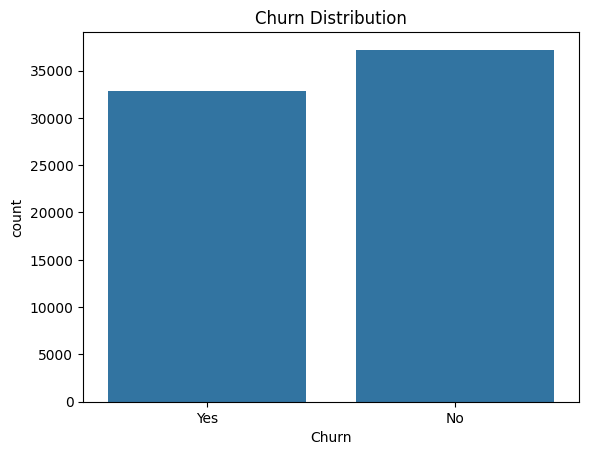

In [33]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

### Insight:
Approximately 27% of customers churned, indicating moderate class imbalance.
This suggests recall should be prioritized during modeling.

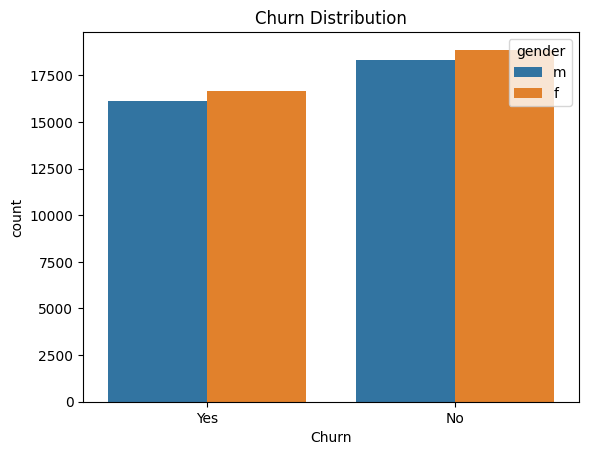

In [34]:
sns.countplot(x='Churn',hue='gender', data=df)
plt.title("Churn Distribution")
plt.show()

In [35]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=['0-1 Yr','1-2 Yr','2-4 Yr','4-6 Yr']
)

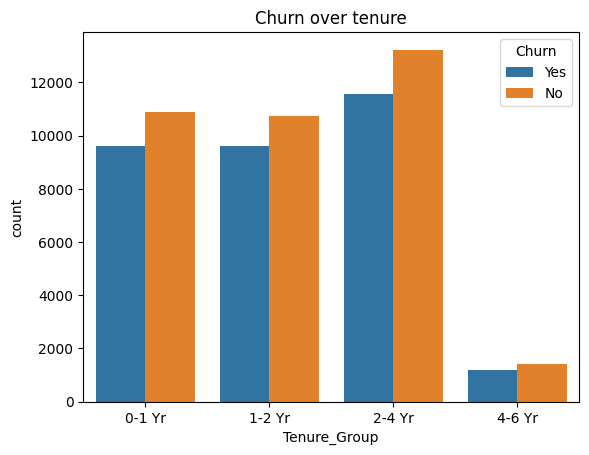

In [36]:
sns.countplot(x='Tenure_Group',hue='Churn',data=df)
plt.title('Churn over tenure')
plt.show()

### Insight:
Customers with lower tenure are more likely to churn, suggesting early lifecycle engagement is critical.

In [37]:
pd.crosstab(df['Tenure_Group'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Tenure_Group,,
0-1 Yr,53.097129,46.902871
1-2 Yr,52.793227,47.206773
2-4 Yr,53.339518,46.660482
4-6 Yr,54.272693,45.727307


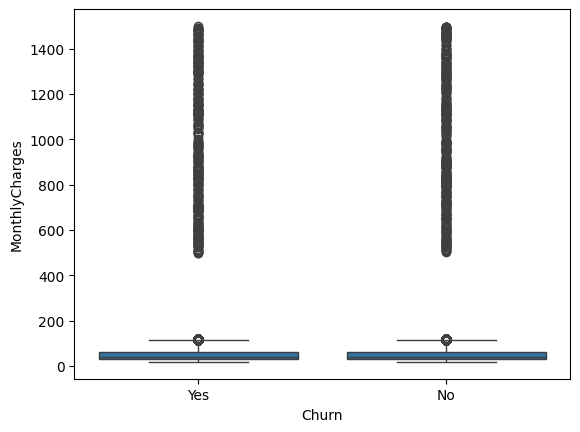

In [38]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [39]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,30.244460,69.755540
One year,80.071352,19.928648
Two year,94.990697,5.009303


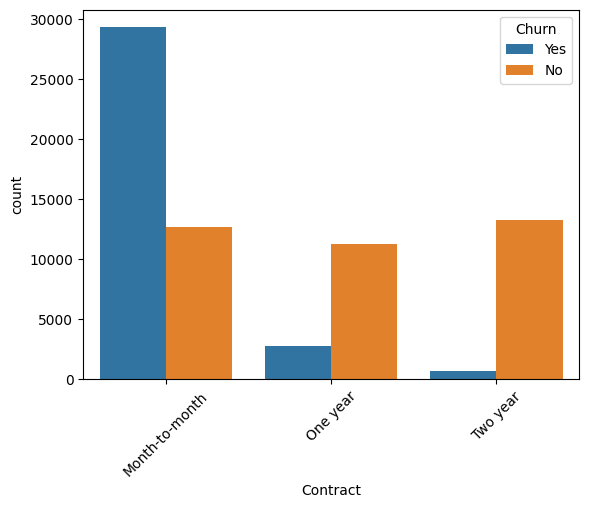

In [40]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

### Insight:
Month-to-month customers show significantly higher churn rate compared to long-term contract customers.
This indicates contract duration is a strong retention factor.

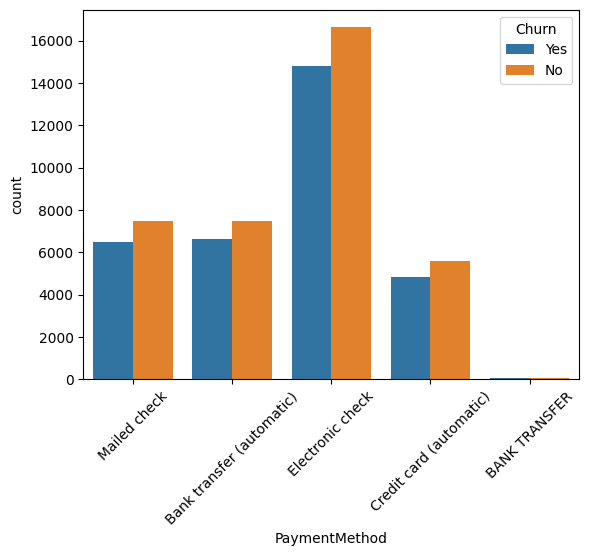

In [41]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.show()

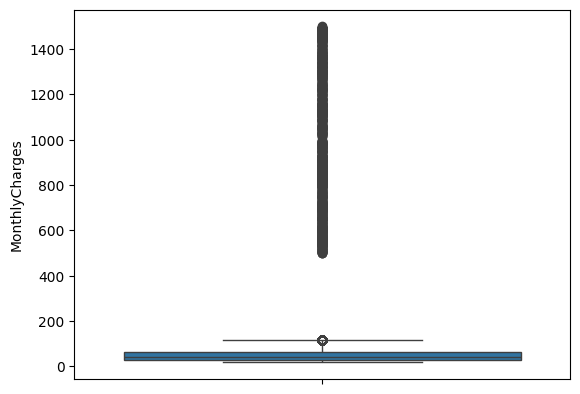

In [42]:
sns.boxplot(y=df['MonthlyCharges'])
plt.show()

####Insight:
This does not means that it has too many outliers, It means monthly charges are large for more service buyer customer.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        70000 non-null  object  
 1   gender            70000 non-null  object  
 2   SeniorCitizen     70000 non-null  object  
 3   Partner           70000 non-null  object  
 4   Dependents        70000 non-null  object  
 5   tenure            70000 non-null  float64 
 6   PhoneService      70000 non-null  object  
 7   MultipleLines     70000 non-null  object  
 8   InternetService   70000 non-null  object  
 9   OnlineSecurity    70000 non-null  object  
 10  OnlineBackup      70000 non-null  object  
 11  DeviceProtection  70000 non-null  object  
 12  TechSupport       70000 non-null  object  
 13  StreamingTV       70000 non-null  object  
 14  StreamingMovies   70000 non-null  object  
 15  Contract          70000 non-null  object  
 16  PaperlessBilling  7000

In [44]:
#customerID not Providing any information about churn prediction
custd_id = df['customerID']
df = df.drop(columns='customerID')

In [45]:
df.shape

(70000, 21)

In [46]:
df['gender']

,gender
0,m
1,m
2,f
3,f
4,m
...,...
69995,m
69996,m
69997,m
69998,m


In [47]:
df['gender'].unique()

array(['m', 'f'], dtype=object)

In [48]:
df['gender'] = df['gender'].map({'m':0,'f':1}).astype(int)

In [49]:
df['gender'].unique()

array([0, 1])

In [50]:
df['SeniorCitizen'].unique()

array(['No', 'Yes'], dtype=object)

In [51]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({'No':0,'Yes':1}).astype(int)

In [52]:
df['SeniorCitizen'].unique()

array([0, 1])

In [53]:
df['Partner'].unique()

array(['No', 'Yes'], dtype=object)

In [54]:
df['Partner'] = df['Partner'].map({'No':0,'Yes':1}).astype(int)

In [55]:
df['Partner'].unique()

array([0, 1])

In [56]:
df['Dependents'].unique()

array(['Yes', 'No'], dtype=object)

In [57]:
df['Dependents'] = df['Dependents'].map({'No':0,'Yes':1}).astype(int)

In [58]:
df['Dependents'].unique()

array([1, 0])

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   gender            70000 non-null  int64   
 1   SeniorCitizen     70000 non-null  int64   
 2   Partner           70000 non-null  int64   
 3   Dependents        70000 non-null  int64   
 4   tenure            70000 non-null  float64 
 5   PhoneService      70000 non-null  object  
 6   MultipleLines     70000 non-null  object  
 7   InternetService   70000 non-null  object  
 8   OnlineSecurity    70000 non-null  object  
 9   OnlineBackup      70000 non-null  object  
 10  DeviceProtection  70000 non-null  object  
 11  TechSupport       70000 non-null  object  
 12  StreamingTV       70000 non-null  object  
 13  StreamingMovies   70000 non-null  object  
 14  Contract          70000 non-null  object  
 15  PaperlessBilling  70000 non-null  object  
 16  PaymentMethod     7000

In [60]:
df['PhoneService'].unique()

array(['Yes', 'No'], dtype=object)

In [61]:
df['PhoneService'] = df['PhoneService'].map({'No':0,'Yes':1}).astype(int)

In [62]:
df['PhoneService'].unique()

array([1, 0])

In [63]:
for col in df:
  if df[col].dtype == 'object':
    print(f"{col} --> ",df[col].unique())

MultipleLines -->  ['Yes' 'No' 'No phone service']
InternetService -->  ['No' 'DSL' 'Fiber optic']
OnlineSecurity -->  ['No internet service' 'No' 'Yes']
OnlineBackup -->  ['No internet service' 'No' 'Yes']
DeviceProtection -->  ['No internet service' 'No' 'Yes']
TechSupport -->  ['No internet service' 'Yes' 'No']
StreamingTV -->  ['No internet service' 'No' 'Yes']
StreamingMovies -->  ['No internet service' 'No' 'Yes']
Contract -->  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -->  ['No' 'Yes']
PaymentMethod -->  ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)' 'BANK TRANSFER']
TotalCharges -->  ['205.83' '46.3' '1790.46' ... '928.62' '982.17' '217.23']
Churn -->  ['Yes' 'No']


In [64]:
df['MultipleLines'] = df['MultipleLines'].map({'Yes':1,'No':0,'No phone service':2}).astype(int)

In [65]:
df['InternetService'] = df['InternetService'].map({'DSL':1,'No':0,'Fiber optic':2}).astype(int)

In [66]:
df['OnlineSecurity'] = df['OnlineSecurity'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [67]:
df['OnlineSecurity'].unique()

array([2, 0, 1])

In [68]:
df['OnlineBackup'] = df['OnlineBackup'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [69]:
df['DeviceProtection'] = df['DeviceProtection'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [70]:
for col in df:
  if df[col].dtype == 'object':
    print(f"{col} --> ",df[col].unique())

TechSupport -->  ['No internet service' 'Yes' 'No']
StreamingTV -->  ['No internet service' 'No' 'Yes']
StreamingMovies -->  ['No internet service' 'No' 'Yes']
Contract -->  ['Month-to-month' 'One year' 'Two year']
PaperlessBilling -->  ['No' 'Yes']
PaymentMethod -->  ['Mailed check' 'Bank transfer (automatic)' 'Electronic check'
 'Credit card (automatic)' 'BANK TRANSFER']
TotalCharges -->  ['205.83' '46.3' '1790.46' ... '928.62' '982.17' '217.23']
Churn -->  ['Yes' 'No']


In [71]:
df['TechSupport'] = df['TechSupport'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)
df['StreamingTV'] = df['StreamingTV'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)
df['StreamingMovies'] = df['StreamingMovies'].map({'Yes':1,'No':0,'No internet service':2}).astype(int)

In [72]:
df['Contract'] = df['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2})

In [73]:
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes':1,'No':0}).astype(int)

In [74]:
df['PaymentMethod'] = df['PaymentMethod'].map({'Mailed check':0 ,'Bank transfer (automatic)':1, 'Electronic check':2,
 'Credit card (automatic)' :3,'BANK TRANSFER':4})

In [75]:
df['Churn'] = df['Churn'].map({'No':0,'Yes':1}).astype(int)

In [76]:
df['TotalCharges'].dtype

dtype('O')

In [77]:
df['TotalCharges'] = df['TotalCharges'].str.replace(r'[^0-9.]', '', regex=True)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [78]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [79]:
df['MonthlyCharges'].dtype

dtype('float64')

In [80]:
df=df.drop(columns='Tenure_Group')

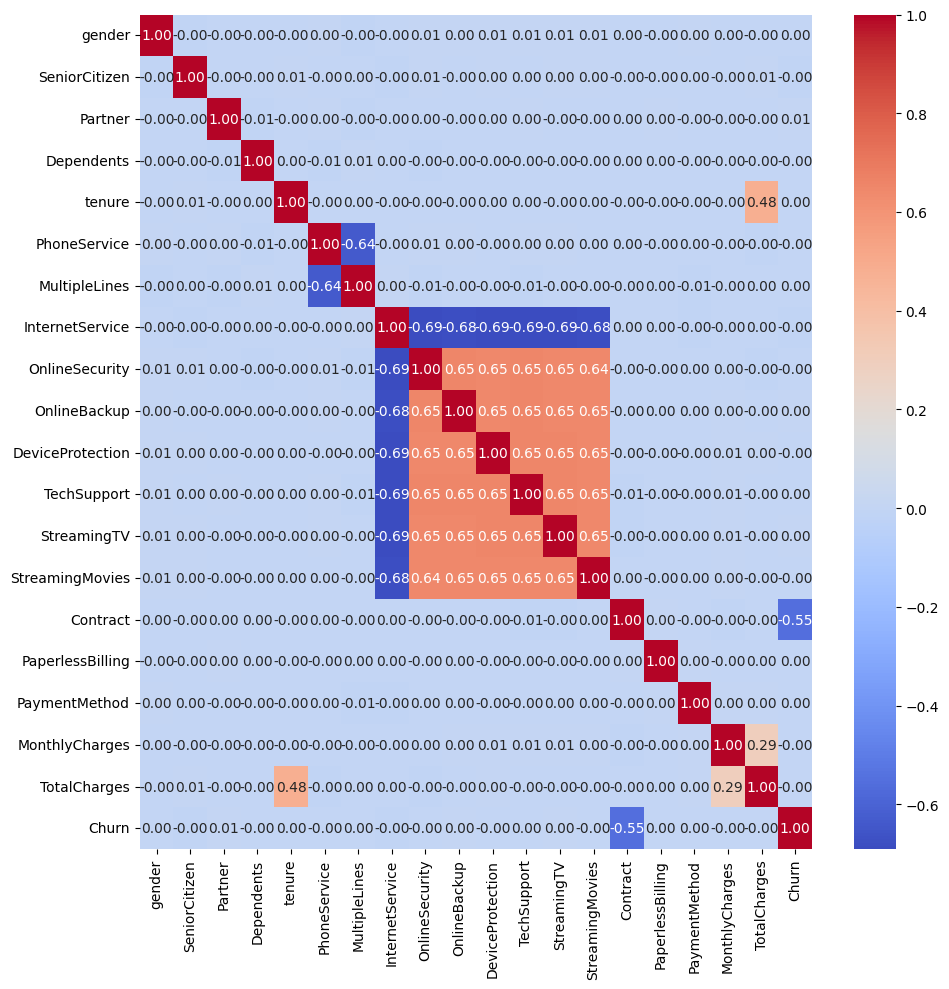

In [81]:
corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,cmap='coolwarm',annot=True,fmt=".2f")
plt.tight_layout()
plt.show()

In [82]:
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,1,3.0,1,1,0,2,2,2,2,2,2,0,0,0,68.61,205.83,1
1,0,1,1,0,2.0,1,1,1,0,0,2,1,0,0,1,1,1,23.15,46.30,0
2,1,0,0,0,42.0,1,1,1,0,1,0,0,1,1,0,0,2,42.63,1790.46,1
3,1,0,0,1,40.0,1,1,2,0,0,1,0,0,2,0,0,2,75.04,3001.60,0
4,0,1,1,1,17.0,1,1,2,1,0,1,0,2,0,2,1,2,22.38,380.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,1,1,1,30.0,1,1,2,1,1,0,1,0,0,2,0,2,74.85,2245.50,0
69996,0,0,1,0,15.0,1,1,2,0,0,0,0,0,0,0,1,1,40.67,610.05,1
69997,0,0,0,0,20.0,1,0,1,1,0,0,0,0,0,0,1,0,29.44,588.80,0
69998,0,0,0,0,21.0,1,0,2,0,1,0,0,1,2,0,1,2,46.77,982.17,0


In [83]:
y = df['Churn']
df = df.drop(columns='Churn')

In [84]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df,y,test_size=0.25,random_state=42)

In [85]:
from sklearn.preprocessing import StandardScaler
scalor = StandardScaler()
x_train_scaled = scalor.fit_transform(x_train)
x_test_scaled = scalor.transform(x_test)

In [86]:
from sklearn.linear_model import LogisticRegression
LReg = LogisticRegression()

In [87]:
LReg.fit(x_train_scaled,y_train)

LogisticRegression()

In [88]:
print("Train Score :",LReg.score(x_train_scaled,y_train))
print("Test Score :",LReg.score(x_test_scaled,y_test))

Train Score : 0.7676190476190476
Test Score : 0.7714857142857143


In [89]:
from sklearn.metrics import roc_auc_score,classification_report
y_pred_proba = LReg.predict_proba(x_test_scaled)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_pred_proba))

Roc_Auc_Score : 0.7925711611338332


In [90]:
y_pred = LReg.predict(x_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      9286
           1       0.70      0.90      0.79      8214

    accuracy                           0.77     17500
   macro avg       0.79      0.78      0.77     17500
weighted avg       0.79      0.77      0.77     17500



In [91]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],  # supports l1
    'class_weight': [None, 'balanced']
}

In [92]:
Rlr = RandomizedSearchCV(estimator=LReg,param_distributions=param_dist,cv=5,random_state=42,scoring='roc_auc')

In [93]:
Rlr.fit(x_train_scaled,y_train)

RandomizedSearchCV(cv=5, estimator=LogisticRegression(),
                   param_distributions={'C': [0.01, 0.1, 1, 10, 100],
                                        'class_weight': [None, 'balanced'],
                                        'penalty': ['l1', 'l2'],
                                        'solver': ['liblinear']},
                   random_state=42, scoring='roc_auc')

In [94]:
print(R"Best Parameter :",Rlr.best_params_)

Best Parameter : {'solver': 'liblinear', 'penalty': 'l1', 'class_weight': None, 'C': 0.01}


In [95]:
print("Train Score :",Rlr.score(x_train_scaled,y_train))
print("Test Score :",Rlr.score(x_test_scaled,y_test))

Train Score : 0.7901729404020252
Test Score : 0.791817475833955


In [96]:
y_rlr_pred_proba = Rlr.predict_proba(x_test_scaled)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_rlr_pred_proba))

Roc_Auc_Score : 0.791817475833955


In [97]:
y_rlr_pred = Rlr.predict(x_test_scaled)
print(classification_report(y_test,y_rlr_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      9286
           1       0.70      0.90      0.79      8214

    accuracy                           0.77     17500
   macro avg       0.79      0.78      0.77     17500
weighted avg       0.79      0.77      0.77     17500



In [98]:
model = Rlr

In [99]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(max_depth=5)

In [100]:
rfc.fit(x_train,y_train)

RandomForestClassifier(max_depth=5)

In [101]:
print("Train Score :",rfc.score(x_train,y_train))
print("Test Score :",rfc.score(x_test,y_test))

Train Score : 0.7676190476190476
Test Score : 0.7714285714285715


In [102]:
y_rfc_pred_proba = rfc.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_rfc_pred_proba))

Roc_Auc_Score : 0.789107630574151


In [103]:
y_rfc_pred = rfc.predict(x_test)
print(classification_report(y_test,y_rfc_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      9286
           1       0.70      0.90      0.79      8214

    accuracy                           0.77     17500
   macro avg       0.79      0.78      0.77     17500
weighted avg       0.79      0.77      0.77     17500



In [104]:
param_dist_1 = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 8],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

In [105]:
Rrfc = RandomizedSearchCV(estimator=rfc,param_distributions=param_dist_1,n_iter = 10,n_jobs=-1,cv=3,random_state=42,scoring='roc_auc')

In [106]:
Rrfc.fit(x_train,y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(max_depth=5),
                   n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [5, 10, 15],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 8],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='roc_auc')

In [107]:
print("Best Parameters :",Rrfc.best_params_)

Best Parameters : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced'}


In [108]:
print("Train Score :",Rrfc.score(x_train,y_train))
print("Test Score :",Rrfc.score(x_test,y_test))

Train Score : 0.8887430116986168
Test Score : 0.7910302344127457


In [109]:
y_Rrfc_pred_proba = Rrfc.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",y_Rrfc_pred_proba)

Roc_Auc_Score : [0.70836643 0.1157522  0.24244231 ... 0.69427195 0.69536311 0.12931376]


In [110]:
y_Rrfc_pred = Rrfc.predict(x_test)
print(classification_report(y_test,y_Rrfc_pred))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      9286
           1       0.70      0.90      0.79      8214

    accuracy                           0.77     17500
   macro avg       0.79      0.78      0.77     17500
weighted avg       0.79      0.77      0.77     17500



In [111]:
from xgboost import XGBClassifier
xgb = XGBClassifier()

In [112]:
xgb.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [113]:
print("Trian Score :",xgb.score(x_train,y_train))
print("Test Score :",xgb.score(x_test,y_test))

Trian Score : 0.788
Test Score : 0.7657142857142857


In [114]:
y_xgb_pred_proba = xgb.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_xgb_pred_proba))

Roc_Auc_Score : 0.7893738179972616


In [115]:
y_xgb_pred = xgb.predict(x_test)
print(classification_report(y_xgb_pred,y_test))

              precision    recall  f1-score   support

           0       0.67      0.86      0.75      7232
           1       0.88      0.70      0.78     10268

    accuracy                           0.77     17500
   macro avg       0.77      0.78      0.76     17500
weighted avg       0.79      0.77      0.77     17500



In [116]:
param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}


In [117]:
Rxg = RandomizedSearchCV(xgb,param_distributions=param_dist,n_iter=20, cv=5,scoring='roc_auc',n_jobs=-1,random_state=42)

In [118]:
Rxg.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrain...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8],
                                        'learning_rate': [0.05, 0.1],
                                        'max_depth': [4, 6],
                                        'n_estimators': [200, 300],
                                        'subsample': [0.8]},
                   random_state=42, scoring='roc_auc')

In [119]:
print("Train_Score :",Rxg.score(x_train,y_train))
print("Test_Score :",Rxg.score(x_test,y_test))

Train_Score : 0.8834418624755304
Test_Score : 0.791540845960897


In [120]:
y_Rxg_pred_proba = Rxg.predict_proba(x_test)[:,1]
print("Roc_Auc_Score :",roc_auc_score(y_test,y_Rxg_pred_proba))

Roc_Auc_Score : 0.791540845960897


In [121]:
y_Rxg_pred = Rxg.predict(x_test)
print(classification_report(y_test,y_Rxg_pred))

              precision    recall  f1-score   support

           0       0.87      0.66      0.75      9286
           1       0.70      0.89      0.78      8214

    accuracy                           0.77     17500
   macro avg       0.79      0.78      0.77     17500
weighted avg       0.79      0.77      0.77     17500



### Insight:
The model achieved 90% recall for churn customers, meaning most at-risk customers were successfully identified.
Precision is moderate, indicating some false positives, which is acceptable in churn prevention scenarios.

In [122]:
import pickle
with open("Churn_model.pkl", "wb") as file:
    pickle.dump(model, file)